# CSDR cloud-spatial SDF API example

This notebook starts at `GET /api/v0/dataset`, then walks the live API step by step. We could use an anonymous session, but the aim is to get a workflow going that uses an API key (you can generate the API key in the SDF cloud-spatial app/admin console).

Here's a rundown of the notebook:
1. Use `API_KEY` when available, otherwise fall back to an anonymous session (see below).
2. Keep the `/api/auth` and `/api/v0` base paths explicit.
3. List datasets and geometry collections.
4. Fetch one dataset and one geometry collection in detail, including provenance.
5. List matching products, fetch one product in detail, and inspect product/dataset/geometries provenance.
6. Export product-run values, show a table, and plot a few simple views.

## Notes on API key setup
You can set your API KEY up a few different ways:
- You could set it via `%env API_KEY=xxxxx` and `os.environ["API_KEY"]` but that is pretty dangerous
- You could use a bash/shell command `!API_KEY='xxxxx'` each time to inject it into the script or notebook, but that might be annoying or not so transferable
- The recommended way is to setup a Secret in whatever platform/environment you're using. The example in this notebook uses a Colab Secret (you create the Secret in your Colab environment, then any notebook can access it) or if running in a local environment it instead looks for the env variable - see the code below where the `API_KEY` variable is defined.

In [ ]:
import os

from matplotlib import cm, colors
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display

try:
    import folium
    from branca.colormap import linear
    from pyproj import Transformer
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "folium", "branca", "pyproj"])
    import folium
    from branca.colormap import linear
    from pyproj import Transformer

try:
    from google.colab import userdata
except ImportError:
    userdata = None

API_BASE_URL = "https://csdr.dev.oceandevelopmentdata.org"
AUTH_BASE_URL = f"{API_BASE_URL}/api/auth"
API_V0_BASE_URL = f"{API_BASE_URL}/api/v0"
TARGET_DATASET_NAME = "Digital Earth Pacific Mangrove Extents"
TARGET_GEOMETRY_NAME = "Pacific Exclusive Economic Zones"
API_KEY = userdata.get("csdr-cloud-spatial-app") if userdata is not None else os.environ.get("CSDR_CLOUD_SPATIAL_APP_API_KEY")

session = requests.Session()
session.headers.update({"Accept": "application/json"})


def auth_post(path: str, payload: dict | None = None):
    response = session.post(f"{AUTH_BASE_URL}{path}", json=payload or {}, timeout=60)
    response.raise_for_status()
    return response.json()


def api_get(path: str):
    response = session.get(f"{API_V0_BASE_URL}{path}", timeout=60)
    response.raise_for_status()
    payload = response.json()
    if payload.get("statusCode") != 200:
        raise RuntimeError(payload)
    return payload["data"]


def api_list(path: str):
    return api_get(path)["data"]


def safe_get(value, *keys, default=None):
    current = value
    for key in keys:
        if not isinstance(current, dict):
            return default
        current = current.get(key)
        if current is None:
            return default
    return current


def select_main_run(resource_name: str, resource_id: str, main_run_id: str | None):
    runs = api_list(f"/{resource_name}/{resource_id}/runs?page=1&size=100")
    if not runs:
        return {}
    return next((run for run in runs if run.get("id") == main_run_id), runs[0])


def build_feature_collection(geometry_outputs, latest_values=None):
    latest_values = latest_values or {}
    features = []
    for item in geometry_outputs:
        value_info = latest_values.get(item["id"], {})
        features.append(
            {
                "type": "Feature",
                "id": item["id"],
                "properties": {
                    "name": item["name"],
                    "geometry_output_id": item["id"],
                    "latest_value": value_info.get("value_display"),
                    "latest_value_label": value_info.get("value_label"),
                    "indicator": value_info.get("indicator_name"),
                },
                "geometry": item["geometry"],
            }
        )
    return {"type": "FeatureCollection", "features": features}


def make_outline_map(feature_collection, title: str):
    fmap = folium.Map(tiles="CartoDB positron")
    geojson = folium.GeoJson(
        feature_collection,
        name=title,
        style_function=lambda _: {
            "color": "#0f172a",
            "weight": 1,
            "fillColor": "#60a5fa",
            "fillOpacity": 0.12,
        },
        tooltip=folium.GeoJsonTooltip(fields=["name"], aliases=["Geometry"]),
    )
    geojson.add_to(fmap)
    fmap.fit_bounds(geojson.get_bounds())
    folium.LayerControl().add_to(fmap)
    return fmap


def make_value_map(feature_collection, display_unit: str, latest_year: int):
    values = [
        feature["properties"]["latest_value"]
        for feature in feature_collection["features"]
        if feature["properties"].get("latest_value") is not None
    ]
    fmap = folium.Map(tiles="CartoDB positron")

    if not values:
        return make_outline_map(feature_collection, "Geometry outputs")

    min_value = min(values)
    max_value = max(values)
    if min_value == max_value:
        max_value = min_value + 1

    colormap = linear.YlGnBu_09.scale(min_value, max_value)
    colormap.caption = f"Latest value ({display_unit}) for {latest_year}"

    def style_function(feature):
        value = feature["properties"].get("latest_value")
        return {
            "color": "#334155",
            "weight": 1,
            "fillColor": "#d1d5db" if value is None else colormap(value),
            "fillOpacity": 0.75 if value is not None else 0.2,
        }

    geojson = folium.GeoJson(
        feature_collection,
        name="Latest product values",
        style_function=style_function,
        tooltip=folium.GeoJsonTooltip(
            fields=["name", "latest_value_label", "indicator"],
            aliases=["Geometry", f"Latest value ({display_unit})", "Indicator"],
        ),
    )
    geojson.add_to(fmap)
    fmap.fit_bounds(geojson.get_bounds())
    colormap.add_to(fmap)
    folium.LayerControl().add_to(fmap)
    return fmap


PACIFIC_PROJECTION = "+proj=robin +lon_0=180 +datum=WGS84 +units=m +no_defs"
PACIFIC_TRANSFORMER = Transformer.from_crs("EPSG:4326", PACIFIC_PROJECTION, always_xy=True)


def iter_exterior_rings(geometry):
    geometry_type = geometry.get("type")
    coordinates = geometry.get("coordinates", [])

    if geometry_type == "Polygon":
        if coordinates:
            yield coordinates[0]
    elif geometry_type == "MultiPolygon":
        for polygon in coordinates:
            if polygon:
                yield polygon[0]


def project_ring(ring):
    xs, ys = PACIFIC_TRANSFORMER.transform(
        [point[0] for point in ring],
        [point[1] for point in ring],
    )
    return list(zip(xs, ys))


def feature_collection_bounds(feature_collection):
    min_x = min_y = float("inf")
    max_x = max_y = float("-inf")

    for feature in feature_collection["features"]:
        for ring in iter_exterior_rings(feature["geometry"]):
            projected_ring = project_ring(ring)
            xs = [point[0] for point in projected_ring]
            ys = [point[1] for point in projected_ring]
            min_x = min(min_x, min(xs))
            min_y = min(min_y, min(ys))
            max_x = max(max_x, max(xs))
            max_y = max(max_y, max(ys))

    return min_x, min_y, max_x, max_y


def build_patch_collection(feature_collection, fill_by_value=False):
    patches = []
    patch_values = []

    for feature in feature_collection["features"]:
        value = feature["properties"].get("latest_value") if fill_by_value else None
        for ring in iter_exterior_rings(feature["geometry"]):
            patches.append(MplPolygon(project_ring(ring), closed=True))
            patch_values.append(value)

    return patches, patch_values


def make_static_outline_map(feature_collection, title: str):
    fig, ax = plt.subplots(figsize=(10, 5.6), dpi=120)
    patches, _ = build_patch_collection(feature_collection, fill_by_value=False)
    collection = PatchCollection(
        patches,
        facecolor=(0.59, 0.78, 0.98, 0.2),
        edgecolor="#0f172a",
        linewidth=0.35,
    )
    ax.add_collection(collection)

    min_x, min_y, max_x, max_y = feature_collection_bounds(feature_collection)
    x_pad = max((max_x - min_x) * 0.04, 1)
    y_pad = max((max_y - min_y) * 0.04, 1)
    ax.set_xlim(min_x - x_pad, max_x + x_pad)
    ax.set_ylim(min_y - y_pad, max_y + y_pad)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_facecolor("#f8fafc")
    ax.axis("off")
    fig.tight_layout()
    return fig


def make_static_value_map(feature_collection, display_unit: str, latest_year: int):
    fig, ax = plt.subplots(figsize=(10, 5.6), dpi=120)
    patches, patch_values = build_patch_collection(feature_collection, fill_by_value=True)
    values = [value for value in patch_values if value is not None]

    if values:
        vmin = min(values)
        vmax = max(values)
        if vmin == vmax:
            vmax = vmin + 1
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
        cmap = cm.get_cmap("YlGnBu")
        facecolors = [
            (0.82, 0.85, 0.87, 0.25) if value is None else cmap(norm(value))
            for value in patch_values
        ]
        collection = PatchCollection(
            patches,
            facecolor=facecolors,
            edgecolor="#334155",
            linewidth=0.35,
        )
        ax.add_collection(collection)
        colorbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.72, pad=0.02)
        colorbar.set_label(f"Latest value ({display_unit}) for {latest_year}")
    else:
        collection = PatchCollection(
            patches,
            facecolor=(0.82, 0.85, 0.87, 0.25),
            edgecolor="#334155",
            linewidth=0.35,
        )
        ax.add_collection(collection)

    min_x, min_y, max_x, max_y = feature_collection_bounds(feature_collection)
    x_pad = max((max_x - min_x) * 0.04, 1)
    y_pad = max((max_y - min_y) * 0.04, 1)
    ax.set_xlim(min_x - x_pad, max_x + x_pad)
    ax.set_ylim(min_y - y_pad, max_y + y_pad)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Latest product values by geometry ({latest_year})")
    ax.set_facecolor("#f8fafc")
    ax.axis("off")
    fig.tight_layout()
    return fig


print("App base:", API_BASE_URL)
print("Auth base:", AUTH_BASE_URL)
print("API v0 base:", API_V0_BASE_URL)

if API_KEY:
    session.headers["x-api-key"] = API_KEY
    auth_mode = "x-api-key header"
    probe = api_get("/dataset?page=1&size=1")
    print("Auth mode:", auth_mode)
    print("Dataset probe rows:", len(probe["data"]))
else:
    anonymous = auth_post("/sign-in/anonymous")
    auth_mode = "anonymous session cookie"
    print("Auth mode:", auth_mode)
    print("Anonymous user:", anonymous["user"]["email"])
    print("Anonymous user id:", anonymous["user"]["id"])

App base: https://csdr.dev.oceandevelopmentdata.org
Auth base: https://csdr.dev.oceandevelopmentdata.org/api/auth
API v0 base: https://csdr.dev.oceandevelopmentdata.org/api/v0


Auth mode: x-api-key header
Dataset probe rows: 1


In [ ]:
dataset_list = api_get("/dataset?page=1&size=50")
datasets_df = pd.DataFrame(dataset_list["data"])

geometries_list = api_get("/geometries?page=1&size=50")
geometries_df = pd.DataFrame(geometries_list["data"])

print(f"Datasets returned: {len(datasets_df)}")
print(f"Geometry collections returned: {len(geometries_df)}")

display(datasets_df[["id", "name", "mainRunId", "createdAt", "sourceUrl", "sourceMetadataUrl"]])
display(geometries_df[["id", "name", "mainRunId", "createdAt", "sourceUrl", "sourceMetadataUrl"]])

Datasets returned: 7
Geometry collections returned: 7


,id,name,mainRunId,createdAt,sourceUrl,sourceMetadataUrl
0,9ddda9fc-8d74-4f3d-867c-0d01eaf1e1e7,Digital Earth Pacific Mangrove Extents,d26792f8-2857-4f1d-bb52-2cfe6f05b437,2026-02-24T01:22:39.095Z,None,None
1,fd0a5b43-a9d4-4e5c-893b-4f6ac71dc9cd,VIDA Buildings,32203ddf-9249-45f5-a67d-9439b1a8306c,2025-12-16T04:58:30.336Z,None,None
2,6486daff-aea2-4bee-b39f-57b82f5c25df,Geoscience Australia Sentinel-2 Coastal Ecosys...,3c3b2dff-9936-4ec6-912c-95e12b379a52,2025-12-12T01:06:51.222Z,None,None
3,f3749ab0-ecf1-4b88-8a3d-893fefb9e1cb,Allen Coral Atlas Reef Extents,873a8788-7e4d-4fe9-85c2-ab66a1345b88,2025-12-03T05:37:27.254Z,None,None
4,9b6875d2-f897-42a7-9923-ee6995e2d90f,Digital Earth Pacific Seagrass Extents,8d8cbcce-4279-45c2-8ab5-3d5cc690add3,2025-11-25T04:29:56.977Z,None,None
5,fc10b123-98ce-45de-974e-b667679506b4,Global Mangrove Watch v3,bb9db2d8-76f8-4e0f-80e8-8dff744e54d2,2025-10-19T23:14:32.126Z,https://zenodo.org/records/6894273,https://zenodo.org/records/6894273
6,5714917f-3549-4a95-9fc4-ff96efbdf311,Global Mangrove Watch v4,5f79eb3c-bd0c-4fff-8f4d-09490689aacb,2025-10-09T07:45:49.196Z,https://zenodo.org/records/12756047,https://zenodo.org/records/12756047


,id,name,mainRunId,createdAt,sourceUrl,sourceMetadataUrl
0,3f13c68c-3655-44c9-89d6-74852cb18fa1,Pacific Exclusive Economic Zones,dbceb6d7-f6c4-5cdf-9faa-728a78caea5a,2026-02-25T01:59:23.617Z,None,None
1,9d27aaae-7d25-4315-9604-2c83e2010c3f,Australian Bureau of Statistics - Australian S...,51cfaf9e-0518-5b0b-b6a3-b63bef9f381b,2025-12-17T22:40:48.863Z,None,None
2,d00ea16b-bc0b-4487-afe1-e8ab72e55991,A test (for WKB),8ccbdcd8-67a9-4756-a634-561ff630e6bd,2025-12-17T05:17:36.448Z,None,None
3,0650d638-7351-47f7-ae6f-efa9a9db1aa3,GA Coastal Waters Areas,4d3ee1b8-285b-5c78-b62c-bb08f0abe637,2025-12-12T04:48:04.037Z,None,None
4,b1bc53d1-e5b2-4532-a029-d131bbe29fdb,Australian Coastal Sediment Compartments - Sec...,47ab8a00-9d9f-5618-bfd2-772261184023,2025-12-11T01:22:33.311Z,None,None
5,abs-asgs-2021-sa2,ABS ASGS 2021 - Statistical Area 2,abs-asgs-2021-sa2-geojson-import-1,2025-12-03T02:59:41.390Z,https://www.abs.gov.au/statistics/standards/au...,https://www.abs.gov.au/statistics/standards/au...
6,9120a989-8207-47ea-bb11-be76b69ddbf0,Global Exclusive Economic Zones,1cad60fb-73d3-5f95-a733-6bde395af587,2025-10-09T08:27:32.563Z,https://marineregions.org/sources.php,https://marineregions.org/download_file.php?na...


In [ ]:
dataset_row = datasets_df.loc[datasets_df["name"] == TARGET_DATASET_NAME].iloc[0]
geometry_row = geometries_df.loc[geometries_df["name"] == TARGET_GEOMETRY_NAME].iloc[0]

dataset_id = dataset_row["id"]
geometries_id = geometry_row["id"]

dataset_detail = api_get(f"/dataset/{dataset_id}")
geometry_detail = api_get(f"/geometries/{geometries_id}")
dataset_main_run = select_main_run("dataset", dataset_id, dataset_detail.get("mainRunId"))
geometry_main_run = select_main_run("geometries", geometries_id, geometry_detail.get("mainRunId"))

display(
    pd.Series(
        {
            "dataset": dataset_detail["name"],
            "dataset_id": dataset_detail["id"],
            "main_run_id": dataset_detail["mainRunId"],
            "run_count": dataset_detail["runCount"],
            "product_count": dataset_detail["productCount"],
            "dataset_data_type": dataset_main_run.get("dataType"),
            "dataset_data_size": dataset_main_run.get("dataSize"),
            "dataset_data_url": dataset_main_run.get("dataUrl"),
            "dataset_provenance_url": dataset_main_run.get("provenanceUrl"),
            "source_metadata_url": safe_get(dataset_main_run, "provenanceJson", "sourceMetadataUrl"),
        }
    )
)

display(
    pd.Series(
        {
            "geometries": geometry_detail["name"],
            "geometries_id": geometry_detail["id"],
            "main_run_id": geometry_detail["mainRunId"],
            "geometry_data_type": geometry_main_run.get("dataType"),
            "geometry_data_size": geometry_main_run.get("dataSize"),
            "geometry_data_url": geometry_main_run.get("dataUrl"),
            "geometry_provenance_url": geometry_main_run.get("provenanceUrl"),
            "source_metadata_url": safe_get(geometry_main_run, "provenanceJson", "sourceMetadataUrl"),
        }
    )
)

dataset                              Digital Earth Pacific Mangrove Extents
dataset_id                             9ddda9fc-8d74-4f3d-867c-0d01eaf1e1e7
main_run_id                            d26792f8-2857-4f1d-bb52-2cfe6f05b437
run_count                                                                 4
product_count                                                             2
dataset_data_type                                           stac-geoparquet
dataset_data_size                                                     81451
dataset_data_url          s3://csdr-public-dev/datasets/dep-mangrove/0-0...
dataset_provenance_url    s3://csdr-public-dev/datasets/dep-mangrove/0-0...
source_metadata_url       https://data.digitalearthpacific.org/#dep_s2_m...
dtype: object

geometries                                  Pacific Exclusive Economic Zones
geometries_id                           3f13c68c-3655-44c9-89d6-74852cb18fa1
main_run_id                             dbceb6d7-f6c4-5cdf-9faa-728a78caea5a
geometry_data_type                                                geoparquet
geometry_data_size                                                   1423055
geometry_data_url          s3://csdr-public-dev/geometries/eez-pacific/0-...
geometry_provenance_url    s3://csdr-public-dev/geometries/eez-pacific/0-...
source_metadata_url                    https://marineregions.org/sources.php
dtype: object

In [ ]:
product_list = api_get(
    f"/product?page=1&size=50&datasetId={dataset_id}&geometriesId={geometries_id}"
)
products_df = pd.DataFrame(product_list["data"])
products_df[["id", "name", "mainRunId", "timePrecision"]]

,id,name,mainRunId,timePrecision
0,5e7cd722-9534-4378-aedb-d5471d8af95a,Digital Earth Pacific Mangrove Extents per Pac...,10cbd732-72a7-593f-a464-84615400b761,year


In [ ]:
product_row = products_df.iloc[0]
product_id = product_row["id"]
product_detail = api_get(f"/product/{product_id}")
product_main_run = product_detail["mainRun"]
product_dataset_run = product_main_run["datasetRun"]
product_geometry_run = product_main_run["geometriesRun"]
product_indicator = product_main_run["outputSummary"]["indicators"][0]["indicator"]

pd.Series(
    {
        "product": product_detail["name"],
        "product_id": product_detail["id"],
        "product_main_run_id": product_detail["mainRunId"],
        "geometries": product_detail["geometries"]["name"],
        "product_data_type": product_main_run["dataType"],
        "product_data_size": product_main_run["dataSize"],
        "product_data_url": product_main_run["dataUrl"],
        "product_provenance_url": product_main_run["provenanceUrl"],
        "dataset_provenance_url": product_dataset_run["provenanceUrl"],
        "geometries_provenance_url": product_geometry_run["provenanceUrl"],
        "dataset_run_id": product_dataset_run["id"],
        "geometries_run_id": product_geometry_run["id"],
        "indicator": product_indicator["name"],
        "indicator_unit": product_indicator["unit"],
        "time_start": product_main_run["outputSummary"]["startTime"],
        "time_end": product_main_run["outputSummary"]["endTime"],
        "output_count": product_main_run["outputSummary"]["outputCount"],
    }
)

product                      Digital Earth Pacific Mangrove Extents per Pac...
product_id                                5e7cd722-9534-4378-aedb-d5471d8af95a
product_main_run_id                       10cbd732-72a7-593f-a464-84615400b761
geometries                                    Pacific Exclusive Economic Zones
product_data_type                                                      parquet
product_data_size                                                        10455
product_data_url             s3://csdr-public-dev/products/dep-mangrove-eez...
product_provenance_url       s3://csdr-public-dev/products/dep-mangrove-eez...
dataset_provenance_url       s3://csdr-public-dev/datasets/dep-mangrove/0-0...
geometries_provenance_url    s3://csdr-public-dev/geometries/eez-pacific/0-...
dataset_run_id                            d26792f8-2857-4f1d-bb52-2cfe6f05b437
geometries_run_id                         dbceb6d7-f6c4-5cdf-9faa-728a78caea5a
indicator                                           

In [ ]:
product_run_id = product_detail["mainRunId"]
export_payload = api_get(f"/product-run/{product_run_id}/outputs/export")
records = export_payload["data"]

df = pd.DataFrame(records)
df["timePoint"] = pd.to_datetime(df["timePoint"], utc=True)
df["year"] = df["timePoint"].dt.year
indicator_name = product_indicator["name"]
indicator_unit = product_indicator["unit"]
value_scale = 1_000_000 if indicator_unit == "m²" else 1
display_unit = "km²" if indicator_unit == "m²" else indicator_unit
df["value_display"] = df["value"] / value_scale
df = df.sort_values(["timePoint", "geometryOutputName"]).reset_index(drop=True)

pd.Series(
    {
        "rows": len(df),
        "year_start": int(df["year"].min()),
        "year_end": int(df["year"].max()),
        "display_unit": display_unit,
        "latest_total_value": round(df.loc[df["year"] == df["year"].max(), "value_display"].sum(), 3),
        "max_value": round(df["value_display"].max(), 3),
        "example_geometry": df.iloc[0]["geometryOutputName"],
        "example_indicator": indicator_name,
    }
)

rows                             216
year_start                      2017
year_end                        2024
display_unit                     km²
latest_total_value          6156.101
max_value                   4631.602
example_geometry      American Samoa
example_indicator      Mangrove Area
dtype: object

In [ ]:
latest_year = int(df["year"].max())
latest = (
    df.loc[df["year"] == latest_year, ["geometryOutputName", "indicatorName", "value_display"]]
    .sort_values("value_display", ascending=False)
    .head(10)
    .rename(columns={"geometryOutputName": "geography", "indicatorName": "indicator", "value_display": f"value ({display_unit})"})
)

latest

,geography,indicator,value (km²)
205,Papua New Guinea,Mangrove Area,4609.4655
209,Solomon Islands,Mangrove Area,548.8111
191,Fiji,Mangrove Area,494.0604
201,New Caledonia,Mangrove Area,319.5440
199,Micronesia,Mangrove Area,90.7248
204,Palau,Mangrove Area,59.1230
213,Vanuatu,Mangrove Area,15.9812
211,Tonga,Mangrove Area,11.1416
208,Samoa,Mangrove Area,2.4090
193,Gilbert Islands,Mangrove Area,1.5906


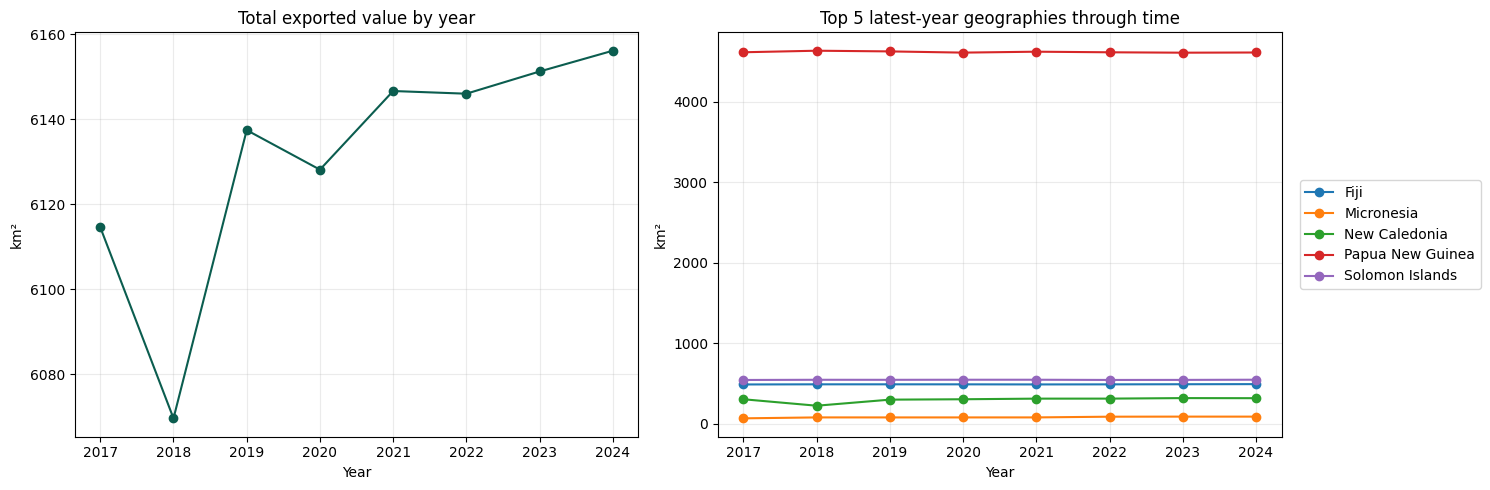

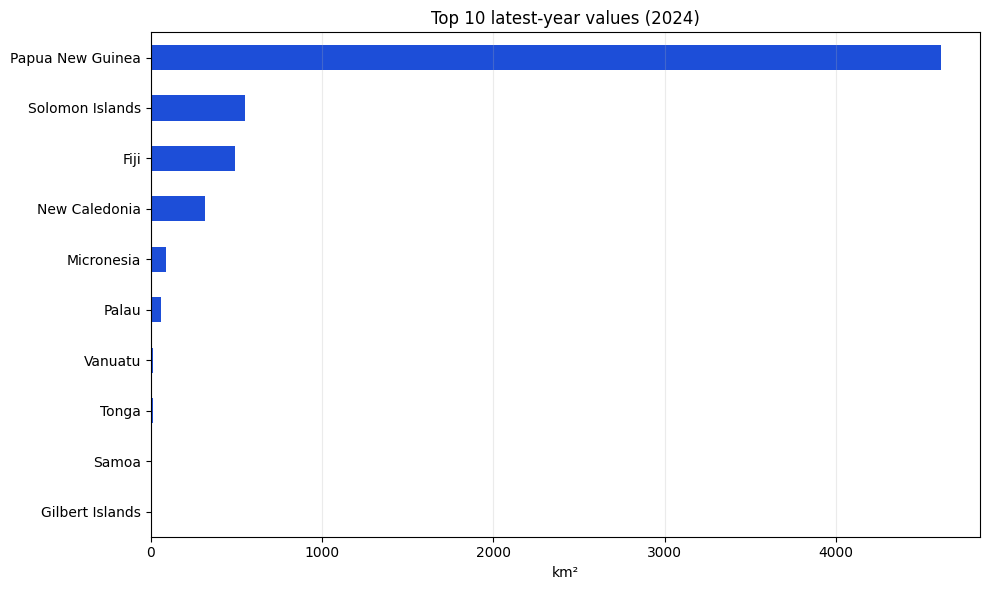

In [ ]:
annual_totals = df.groupby("year", as_index=False)["value_display"].sum()
top_geographies = latest["geography"].head(5).tolist()
top_series = (
    df[df["geometryOutputName"].isin(top_geographies)]
    .pivot(index="year", columns="geometryOutputName", values="value_display")
    .sort_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(annual_totals["year"], annual_totals["value_display"], marker="o", color="#0b5d4f")
axes[0].set_title("Total exported value by year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel(display_unit)
axes[0].grid(alpha=0.25)

for geography in top_series.columns:
    axes[1].plot(top_series.index, top_series[geography], marker="o", label=geography)
axes[1].set_title("Top 5 latest-year geographies through time")
axes[1].set_xlabel("Year")
axes[1].set_ylabel(display_unit)
axes[1].grid(alpha=0.25)
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
value_column = f"value ({display_unit})"
latest.sort_values(value_column).plot.barh(x="geography", y=value_column, ax=ax, color="#1d4ed8", legend=False)
ax.set_title(f"Top 10 latest-year values ({latest_year})")
ax.set_xlabel(display_unit)
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## Map the geometry collection and latest product values

The API exposes geometry outputs directly through `GET /api/v0/geometries-run/:id/outputs/export`, so we can render the selected geometry collection without downloading sidecar files. The dataset itself is discoverable here too, but for this example it points to `stac-geoparquet` in S3 rather than a direct HTTP download, so the notebook maps the geometry collection and overlays the latest product values.


dataset_name                              Digital Earth Pacific Mangrove Extents
dataset_run_id                              d26792f8-2857-4f1d-bb52-2cfe6f05b437
dataset_data_type                                                stac-geoparquet
dataset_data_url               s3://csdr-public-dev/datasets/dep-mangrove/0-0...
dataset_source_metadata_url    https://data.digitalearthpacific.org/#dep_s2_m...
geometry_output_count                                                         27
mapped_year                                                                 2024
dtype: object

/var/folders/7q/dpb3ypr97g38bkw8qf6jdn200000gn/T/ipykernel_81670/187102515.py:252: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlGnBu")


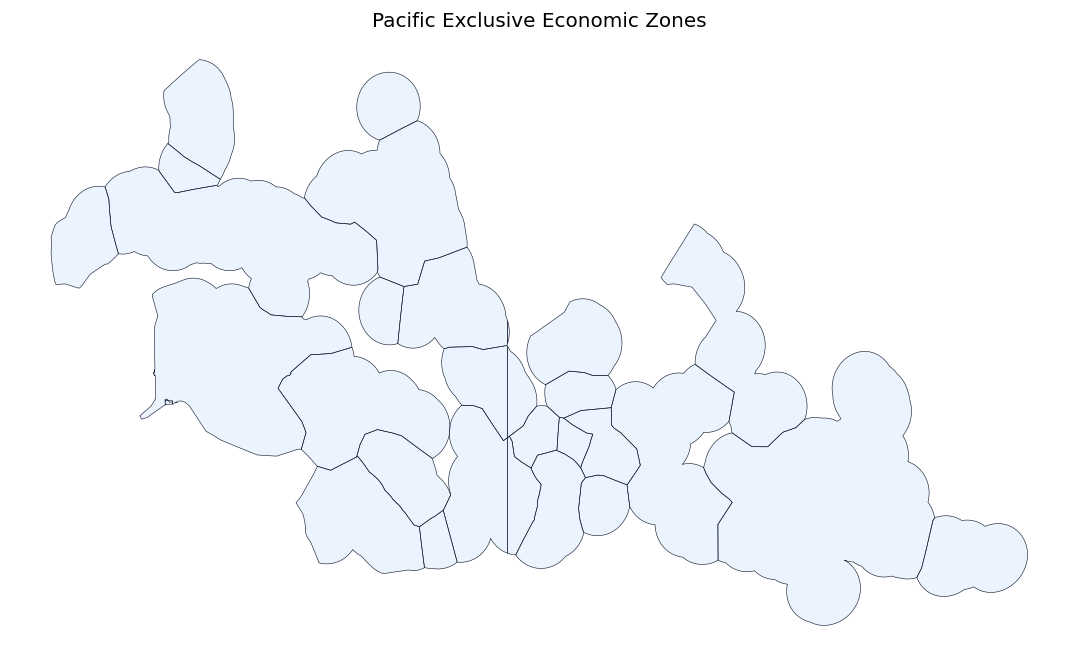

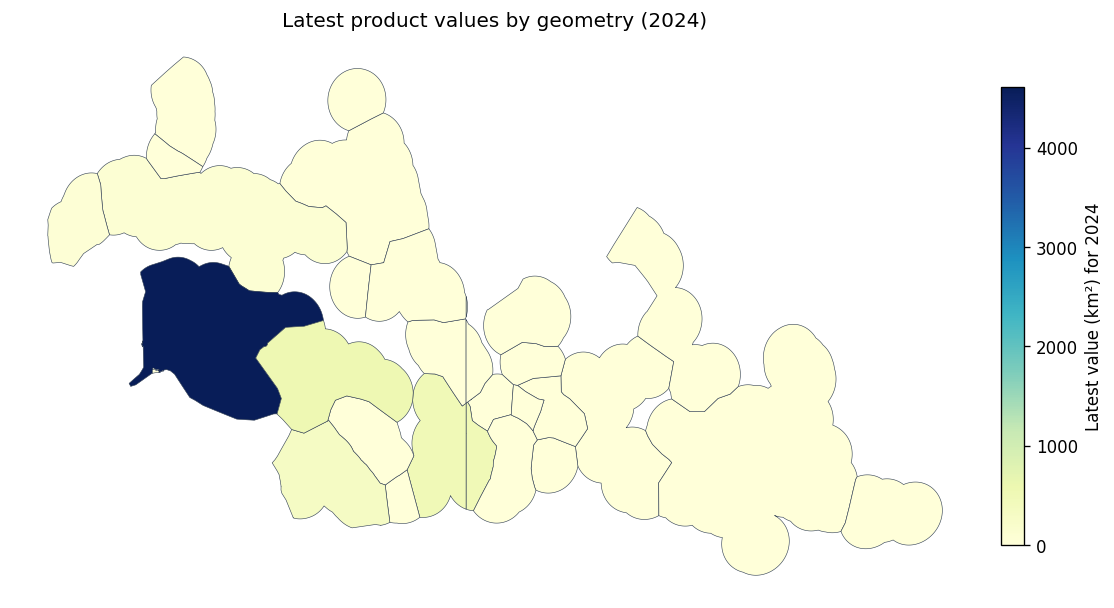

In [ ]:
geometry_outputs_payload = api_get(f"/geometries-run/{geometry_main_run['id']}/outputs/export")
geometry_outputs = geometry_outputs_payload["data"]

latest_rows = df.loc[df["year"] == latest_year].copy()
latest_rows["value_label"] = latest_rows["value_display"].map(lambda value: f"{value:,.2f}")
latest_value_lookup = {
    row["geometryOutputId"]: {
        "value_display": row["value_display"],
        "value_label": f"{row['value_label']} {display_unit}",
        "indicator_name": row["indicatorName"],
    }
    for _, row in latest_rows.iterrows()
}

feature_collection = build_feature_collection(geometry_outputs, latest_value_lookup)

dataset_preview = pd.Series(
    {
        "dataset_name": dataset_detail["name"],
        "dataset_run_id": dataset_main_run.get("id"),
        "dataset_data_type": dataset_main_run.get("dataType"),
        "dataset_data_url": dataset_main_run.get("dataUrl"),
        "dataset_source_metadata_url": safe_get(dataset_main_run, "provenanceJson", "sourceMetadataUrl"),
        "geometry_output_count": len(geometry_outputs),
        "mapped_year": latest_year,
    }
)
display(dataset_preview)

geometry_outline_map = make_outline_map(feature_collection, geometry_detail["name"])
latest_value_map = make_value_map(feature_collection, display_unit, latest_year)
static_geometry_outline = make_static_outline_map(feature_collection, geometry_detail["name"])
static_latest_value_map = make_static_value_map(feature_collection, display_unit, latest_year)

In [ ]:
display(geometry_outline_map)
display(static_geometry_outline)
plt.close(static_geometry_outline)

In [ ]:
display(latest_value_map)
display(static_latest_value_map)
plt.close(static_latest_value_map)